In [1]:
import sys
sys.path.insert(0,'/hdd/miles/velocity_cfm/dnnlib')
from util import Vanderpol,DoubleCircles,DoubleSDE,Lorenz63,Lorenz96,Rossler,projection,Balls
import torch
import numpy as np
import matplotlib.pyplot as plt
import tphate

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [2]:
gen = Lorenz63()
dataTrain = gen.generate(n=50,T=1,dt=0.01,sigma=0.5)
dataTest = gen.generate(n=20,T=1,dt=0.01,sigma=0.5)
p = projection(origDim=3,newDim=5,projType='swish',temp=1.5)

projectedTrain,projectedTest = [p.project(traj) for traj in dataTrain], [p.project(traj) for traj in dataTest]
labelsTrain = [(ii +1)*np.ones((len(t),),dtype=np.int16) for ii,t in enumerate(projectedTrain)]
labelsTest = [(ii+1 + labelsTrain[-1])*np.ones((len(t),),dtype=np.int16) for ii,t in enumerate(projectedTest)]

In [3]:
def compare_representations(true,embedding,plottype='scatter',plotname='./test_model_comparison.png'):
    
    true = np.vstack(true)
    embedding = np.vstack(embedding)
    
    fig = plt.figure(figsize=(10,10))
    
    if (true.shape[-1] == 1) or (len(true.shape) == 1):
        ax = plt.gca()
        trueCounts, trueBins = np.histogram(true,bins=100,density=True)
        embedCounts,embedBins = np.histogram(embedding,bins=trueBins,density=True)
        
        t = ax.stairs(trueCounts,trueBins,edgecolor='#C9303E') #etruscan red
        e = ax.stairs(embedCounts,embedBins,edgecolor='#B4F0D8') #nile blue
        ax.set_xlabel("Data/embed values")
        ax.set_ylabel("Density")
        

    elif true.shape[-1] == 2:
        ax = plt.gca()
        if plottype == 'scatter':
            t = ax.scatter(true[:,0],true[:,1],color='#C9303E',alpha=0.45) #etruscan red
            e = ax.scatter(embedding[:,0],embedding[:,1],color='#B4F0D8',alpha=0.45) #nile blue
        elif plottype == 'line':
            t = ax.plot(true[:,0],true[:,1],color='#C9303E',alpha=0.45) #etruscan red
            e = ax.plot(embedding[:,0],embedding[:,1],color='#B4F0D8',alpha=0.45) #nile blue

        
        ax.set_xlabel('x1')
        ax.set_ylabel('x2')
        ax.set_xticks([])
        ax.set_yticks([])
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
    
    
    elif true.shape[-1] == 3:
        ax1 = fig.add_subplot(121,projection='3d')
        ax2 = fig.add_subplot(122,projection='3d')
        if plottype == 'scatter':
            t = ax1.scatter(true[:,0],true[:,1],true[:,2],color='#C9303E',alpha=0.45) #etruscan red
            e = ax2.scatter(embedding[:,0],embedding[:,1],embedding[:,2],color='#B4F0D8',alpha=0.45) #nile blue
        elif plottype == 'line':
            t = ax1.plot(true[:,0],true[:,1],true[:,2],color='#C9303E',alpha=0.45) #etruscan red
            e = ax2.plot(embedding[:,0],embedding[:,1],embedding[:,2],color='#B4F0D8',alpha=0.45) #nile blue

        ax1.set_xlabel('x1')
        ax1.set_ylabel('x2')
        ax1.set_zlabel('x3')
        ax1.set_xticks([])
        ax1.set_yticks([])
        ax1.set_zticks([])
        ax1.spines['top'].set_visible(False)
        ax1.spines['right'].set_visible(False)
        ax2.set_xlabel('x1')
        ax2.set_ylabel('x2')
        ax2.set_zlabel('x3')
        ax2.set_xticks([])
        ax2.set_yticks([])
        ax2.set_zticks([])
        #ax2.xaxis._axinfo['juggled'] = (0,0,0)
        #ax2.spines['top'].set_visible(False)
        #ax2.spines['right'].set_visible(False)

    
    leg = plt.legend([t,e],['data','embedding'])
   # print(leg.legendHandles)
    for lh in leg.legend_handles: 
        lh.set_alpha(1)
    
    plt.show()
    plt.close()


In [4]:
tphate_op = tphate.TPHATE(n_jobs=4, verbose=1, t='auto', \
                          mds='metric', mds_solver='sgd', smooth_window=4,gamma=1,n_components=3)
embedding = tphate_op.fit_transform(np.vstack(projectedTrain))

Calculating TPHATE...
  Running TPHATE on 5000 observations and 5 variables.
  Landmarking not recommended; setting n_landmark to 5000
  Calculating graph and diffusion operator...
    Calculating KNN search...
    Calculated KNN search in 0.05 seconds.
    Calculating affinities...
    Calculated affinities in 0.03 seconds.
  Calculated graph and diffusion operator in 0.09 seconds.
  Learning the autocorrelation function...
  Calculating Autocorr kernel...
    Dropoff point: 21
  Combining PHATE operator and autocorr operator
  Calculating optimal t...
    Automatically selected t = 27
  Calculated optimal t in 28.85 seconds.
  Calculating diffusion potential...
  Calculated diffusion potential in 13.26 seconds.
  Calculating metric MDS...
  Calculated metric MDS in 608.22 seconds.
Calculated TPHATE in 655.88 seconds.


In [6]:
embed_test = tphate_op.transform(np.vstack(projectedTest))

Calculating KNN search...
Calculated KNN search in 0.02 seconds.
Calculating affinities...
Calculated affinities in 0.01 seconds.


/home/miles/anaconda3/envs/flow_env/lib/python3.8/site-packages/tphate/tphate.py:752: RuntimeWarning: Pre-fit TPHATE should not be used to transform a new data matrix. Please fit TPHATE to the new data by running 'fit' with the new data.
  warnings.warn(


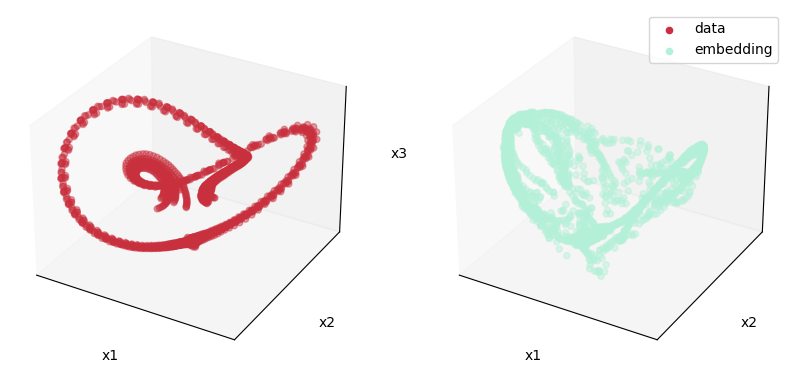

In [8]:
compare_representations(np.vstack(dataTest),embed_test)